# 使用块的网络 VGG

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

def vgg_block(num_convs,in_chanels,out_chanels):
    
    layers=[]
    for _ in range(num_convs):
        layers.append(
            nn.Conv2d(in_chanels,out_chanels,kernel_size=3,padding=1)
        )
        layers.append(nn.ReLU())
        in_chanels=out_chanels
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

In [3]:
conv_arch = ((1, 64), (1, 128), (2,56), (2, 512), (2, 512))
def vgg(conv_arch):

    conv_blks=[]
    in_chanels=1
    for (num_conv,out_chanels) in conv_arch:
        conv_blks.append(
            vgg_block(num_conv,in_chanels,out_chanels)
        )
        in_chanels=out_chanels
    return nn.Sequential(
        *conv_blks,nn.Flatten(),
        nn.Linear(out_chanels*7*7,4096),nn.ReLU(),nn.Dropout(p=0.5),
        nn.Linear(4096,4096),nn.ReLU(),nn.Dropout(p=0.5),
        nn.Linear(4096,10)
    )
net=vgg(conv_arch)


In [4]:
X = torch.rand(size=(1, 1, 224, 224), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Sequential output shape: 	 torch.Size([1, 64, 112, 112])
Sequential output shape: 	 torch.Size([1, 128, 56, 56])
Sequential output shape: 	 torch.Size([1, 56, 28, 28])
Sequential output shape: 	 torch.Size([1, 512, 14, 14])
Sequential output shape: 	 torch.Size([1, 512, 7, 7])
Flatten output shape: 	 torch.Size([1, 25088])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 4096])
ReLU output shape: 	 torch.Size([1, 4096])
Dropout output shape: 	 torch.Size([1, 4096])
Linear output shape: 	 torch.Size([1, 10])


In [5]:
ratio = 4
small_conv_arch = [(pair[0], pair[1] // ratio) for pair in conv_arch]
net = vgg(small_conv_arch)

loss 0.169, train acc 0.937, test acc 0.924
1126.3 examples/sec on cuda:0


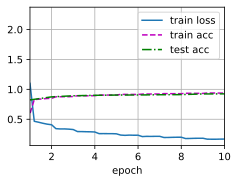

In [6]:
lr, num_epochs, batch_size = 0.05, 10, 128
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

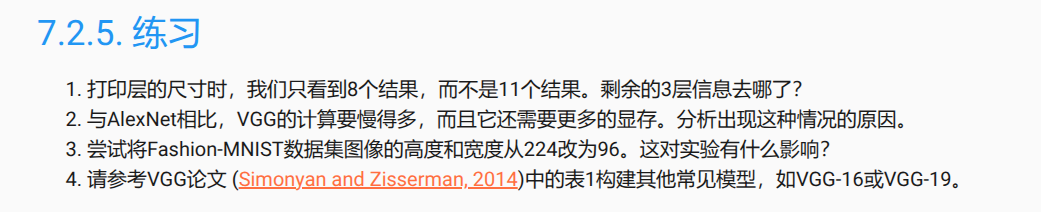